In [164]:
import kagglehub
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

#Listing file in that directory to confirm the exact file name 
files= os.listdir(path)
print(f"File in directory: {files}")


Path to dataset files: /kaggle/input/datasets/johnsmith88/heart-disease-dataset
File in directory: ['heart.csv']


In [165]:
csv_file_path=os.path.join(path,"heart.csv")
df=pd.read_csv(csv_file_path)

#showing first 5 dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [166]:
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0    

## Data Cleaning & Preprocessing

In [167]:
# Missing values
print("Missing Values:\n" ,  df.isnull().sum())

# Duplicates values
print("Duplicate count",df.duplicated().sum())

# statistical overview for outlier detection
df.describe()

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Duplicate count 723


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Basic Questions

In [168]:
# Average Age of Patients
avg_age=df["age"].mean()
print(f"Average Patient Age: {avg_age:.2f} years")

Average Patient Age: 54.43 years


In [169]:
# Gender Distribution of Patients
gender_counts=df["sex"].value_counts()
print("Gender Count :",gender_counts)
gender_pct=(df["sex"].value_counts(normalize=True)*100).round(2)
gender_pct
# 1 - Male
# 0- Female

Gender Count : sex
1    713
0    312
Name: count, dtype: int64


sex
1    69.56
0    30.44
Name: proportion, dtype: float64

> Targeted Outreach: Don't waste budget running generic ads. Direct screening campaigns specifically toward the highest-risk demographic : **(Male 50-60)**

> Descriptive Statistics of Clinical measurements

In [170]:
# Average Resting Blood Presssure 
avg_bp=df["trestbps"].mean().round(2)
print("Average Resting Blood Pressure",avg_bp)

Average Resting Blood Pressure 131.61


In [171]:
# Patients with High Fasting Blood Sugar
high_fbs_count=df["fbs"].value_counts()
print(high_fbs_count)

fbs_prop=(df["fbs"].value_counts(normalize=True)*100).round(0)
print("propotions:",fbs_prop)
# 1 - True
# 2 - False


fbs
0    872
1    153
Name: count, dtype: int64
propotions: fbs
0    85.0
1    15.0
Name: proportion, dtype: float64


> Doctors can catch high blood pressure early and prescribe simple diet changes or pills before patients suffer a heart attack that requires expensive ICU care.

In [172]:
#Types of Chest Pain Recorded
chestpain=df["cp"].unique()

cp_dist=(df["cp"].value_counts(normalize=True)*100).sort_index().round(2)
print(f"cp_dist: {cp_dist} %")

cp_dist: cp
0    48.49
1    16.29
2    27.71
3     7.51
Name: proportion, dtype: float64 %


> Emergency room nurses can prioritize patients with dangerous chest pain first, saving lives and speeding up hospital triage

In [173]:
# Maximum Heart Rate Achieved
heart_rate=df["thalach"].max()
print(f"Maximum heart rate : {heart_rate} bpm")

Maximum heart rate : 202 bpm


> Rehab trainers can give patients safe exercise routines so they do not overwork their heart during recovery.

In [174]:
# Percentage of Patients with Exercise-Induced Angina
# exang: 1=yes, 0 = no
exang_pct=df["exang"].mean()*100
print(f"{exang_pct:.2f} %")

33.66 %


>  Preventative Care Programs: Route these patients to nutritional coaching or early checkups to prevent expensive emergency room visits later.
> 
> Pain type 1
> Cholestrol Serum : 246.00 mg/dl

In [175]:
# Average Serum Cholesterol Level
avg_chol=df["chol"].mean()
print(f"Average Serum Cholestrol Level: {avg_chol:.2f} mg/dl")


Average Serum Cholestrol Level: 246.00 mg/dl


> Helps clinics order the right medicines in bulk and launch diet counseling programs to prevent costly bypass surgeries

In [176]:
# Patients with Resting ECG Result of 2
count_restecg2 =df["restecg"].value_counts().sort_values(ascending=True).head(1)
pct_rest=(df["restecg"]==2).mean()*100
print(f"Patient with RestECG=2 : {pct_rest}")


Patient with RestECG=2 : 1.4634146341463417


> Flags high-priority candidates for echocardiograms and advanced cardiology consultations before acute decompensation occurs

In [177]:
# 10 Distribution of Major Vessels Colored by Fluoroscopy
ca_dist=df["ca"].value_counts().sort_index()
ca_pct=(df["ca"].value_counts(normalize=True)*100).sort_index()

ca_summary=pd.DataFrame({
    "Count": ca_dist,
    "Percentage(%)": ca_pct.round(0) 
})
print(ca_summary)

    Count  Percentage(%)
ca                      
0     578           56.0
1     226           22.0
2     134           13.0
3      69            7.0
4      18            2.0


> The hospital can reserve operating rooms and surgical teams ahead of time for patients with multiple blockages.

## Medium Questions

Correlation Matrix:/n             age      chol
age   1.000000  0.219823
chol  0.219823  1.000000


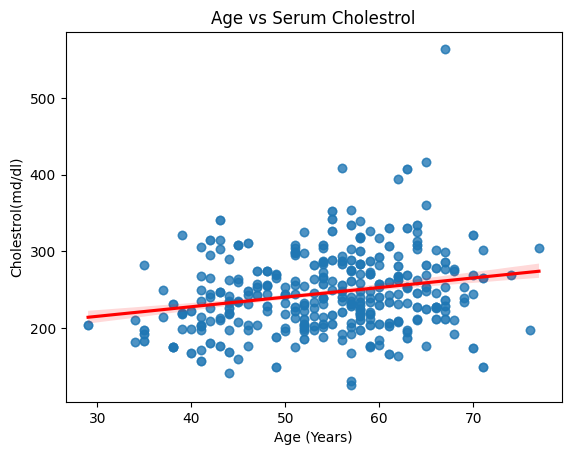

In [178]:
# 1.Correlation Between Age and Cholesterol Levels

age_corr_chol=df[["age","chol"]].corr()
print(f"Correlation Matrix:/n ",age_corr_chol)

# Scatter Plot to visualise 
sns.regplot(data=df,
           x="age", y="chol",scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title("Age vs Serum Cholestrol")
plt.xlabel("Age (Years)")
plt.ylabel("Cholestrol(md/dl)")
plt.show()

> Helps HealthPulse Analytics set automatic age-based checkup alerts so older age groups get lipid screenings before dangerous buildup happens.

cp            0     1     2     3
age_group                        
20-39      33.8  16.2  35.3  14.7
40-49      38.5  26.3  32.8   2.4
50-59      51.4  15.8  25.1   7.8
60-69      58.3   6.3  24.6  10.7
70+        35.0  30.0  35.0   0.0
cp            0     1     2     3
age_group                        
20-39      33.8  16.2  35.3  14.7
40-49      38.5  26.3  32.8   2.4
50-59      51.4  15.8  25.1   7.8
60-69      58.3   6.3  24.6  10.7
70+        35.0  30.0  35.0   0.0


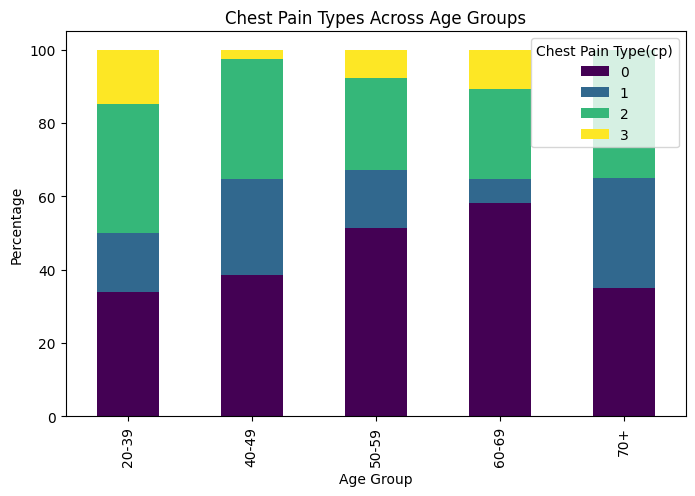

In [179]:
# 2. Chest Pain Types Across Age Groups
# Bin age into decade groups for clearer comparisions
age_bin=[20,40,50,60,70,90]
age_labels=["20-39","40-49","50-59","60-69","70+"]

#
df["age_group"]=pd.cut(df["age"],bins=age_bin,labels=age_labels)
cp_by_age=df.groupby("age_group",observed=False)["cp"].value_counts(normalize=True).unstack()*100
print(cp_by_age.round(1))

# Stacked Bar Plot
cp_by_age.plot(kind="bar",stacked=True,colormap="viridis",figsize=(8,5))
plt.title("Chest Pain Types Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.legend(title="Chest Pain Type(cp)")
print(cp_by_age.round(1))

> Helps emergency and clinic teams spot patterns (like older patients reporting atypical or silent pain), preventing misdiagnoses and delays in emergency treatment

Heart Rate by Exercise Angina Status:
        count    mean  median    std
exang                              
0        680  155.34   159.5  21.51
1        345  136.84   138.0  20.83


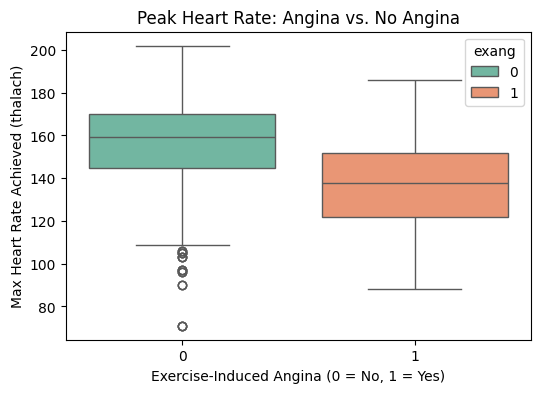

In [180]:
# Maximum Heart Rate (thalach) vs. Exercise-Induced Angina (exang)
hr_angina = df.groupby('exang')['thalach'].agg(['count', 'mean', 'median', 'std'])
print("Heart Rate by Exercise Angina Status:\n", hr_angina.round(2))

# Boxplot comparison
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='exang', y='thalach', palette='Set2',hue="exang")
plt.title('Peak Heart Rate: Angina vs. No Angina')
plt.xlabel('Exercise-Induced Angina (0 = No, 1 = Yes)')
plt.ylabel('Max Heart Rate Achieved (thalach)')
plt.show()

In [181]:
# Resting Blood Pressure Difference Between Men and Women
from scipy import stats

bp_by_sex = df.groupby('sex')['trestbps'].agg(['count', 'mean', 'std'])
print("Blood Pressure by Sex:\n", bp_by_sex.round(2))

# Hypothesis test (Independent Two-Sample T-test)
male_bp = df[df['sex'] == 1]['trestbps']
female_bp = df[df['sex'] == 0]['trestbps']

t_stat, p_val = stats.ttest_ind(male_bp, female_bp, equal_var=False)
print(f"\nT-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

Blood Pressure by Sex:
      count   mean    std
sex                     
0      312  133.7  19.58
1      713  130.7  16.46

T-statistic: -2.369, p-value: 0.0182


Crosstab (% within FBS category):
 target      0      1
fbs                 
0       47.82  52.18
1       53.59  46.41


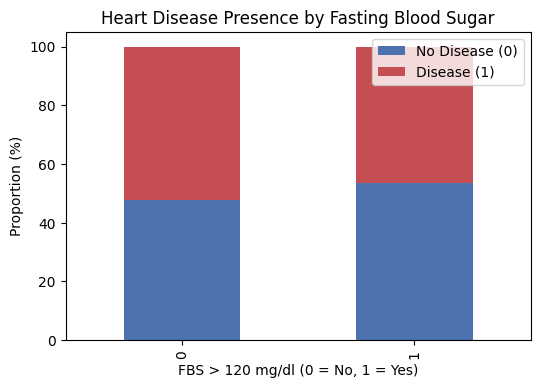

In [182]:
# 5 Fasting Blood Sugar (fbs) vs. Heart Disease Diagnosis (target)
fbs_target_crosstab = pd.crosstab(df['fbs'], df['target'], normalize='index') * 100
print("Crosstab (% within FBS category):\n", fbs_target_crosstab.round(2))

# Stacked bar plot
fbs_target_crosstab.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'], figsize=(6, 4))
plt.title('Heart Disease Presence by Fasting Blood Sugar')
plt.xlabel('FBS > 120 mg/dl (0 = No, 1 = Yes)')
plt.ylabel('Proportion (%)')
plt.legend(['No Disease (0)', 'Disease (1)'], loc='upper right')
plt.show()

Heart Disease Rate by Number of Blocked Vessels (%):
 target      0      1
ca                  
0       28.20  71.80
1       70.80  29.20
2       84.33  15.67
3       86.96  13.04
4       16.67  83.33


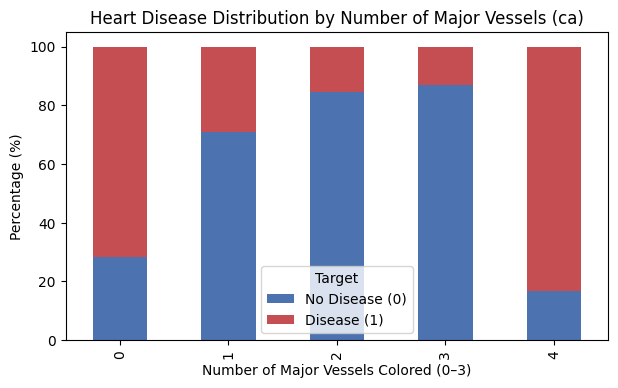

In [183]:
# Major Vessels Colored by Fluoroscopy (ca) vs. Heart Disease (target)
# Crosstab between major vessels and heart disease presence
ca_target_crosstab = pd.crosstab(df['ca'], df['target'], normalize='index') * 100
print("Heart Disease Rate by Number of Blocked Vessels (%):\n", ca_target_crosstab.round(2))

# Stacked bar plot
ca_target_crosstab.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'], figsize=(7, 4))
plt.title('Heart Disease Distribution by Number of Major Vessels (ca)')
plt.xlabel('Number of Major Vessels Colored (0–3)')
plt.ylabel('Percentage (%)')
plt.legend(['No Disease (0)', 'Disease (1)'], title='Target')
plt.show()

Oldpeak Values by Chest Pain Type:
     count  mean  median   std
cp                           
0     497  1.44     1.2  1.30
1     167  0.32     0.0  0.51
2     284  0.78     0.5  0.93
3      77  1.38     1.2  1.14


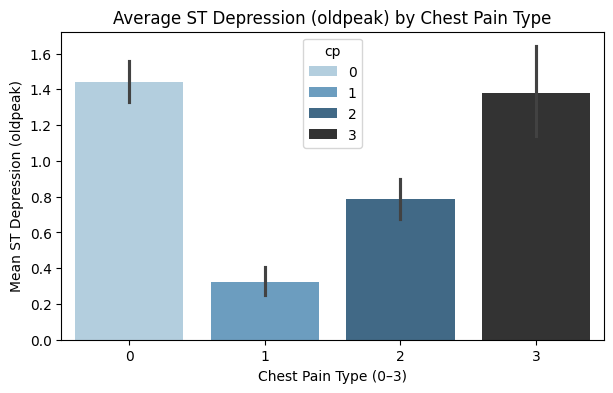

In [184]:
# Average ST Depression (oldpeak) Across Chest Pain Types (cp)
# Grouping by chest pain type to find mean oldpeak (ST depression)
oldpeak_by_cp = df.groupby('cp')['oldpeak'].agg(['count', 'mean', 'median', 'std'])
print("Oldpeak Values by Chest Pain Type:\n", oldpeak_by_cp.round(2))

# Bar plot
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='cp', y='oldpeak', palette='Blues_d',hue="cp")
plt.title('Average ST Depression (oldpeak) by Chest Pain Type')
plt.xlabel('Chest Pain Type (0–3)')
plt.ylabel('Mean ST Depression (oldpeak)')
plt.show()

Heart Disease Rate by Thalassemia Category (%):
 target      0      1
thal                
0       57.14  42.86
1       67.19  32.81
2       24.26  75.74
3       78.05  21.95


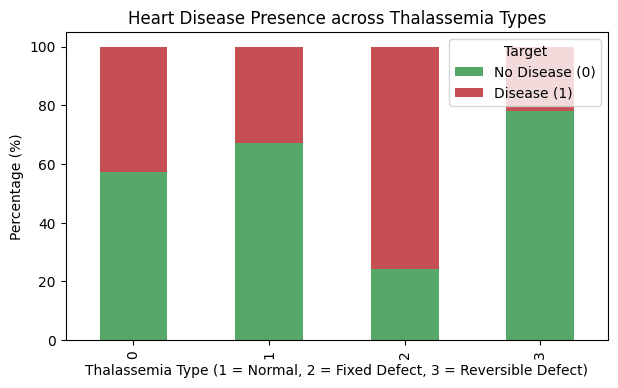

In [185]:
# Thalassemia Types (thal) Among Heart Disease Patients
# Crosstab between thalassemia blood disorder types and target
thal_target = pd.crosstab(df['thal'], df['target'], normalize='index') * 100
print("Heart Disease Rate by Thalassemia Category (%):\n", thal_target.round(2))

# Stacked bar plot
thal_target.plot(kind='bar', stacked=True, color=['#55A868', '#C44E52'], figsize=(7, 4))
plt.title('Heart Disease Presence across Thalassemia Types')
plt.xlabel('Thalassemia Type (1 = Normal, 2 = Fixed Defect, 3 = Reversible Defect)')
plt.ylabel('Percentage (%)')
plt.legend(['No Disease (0)', 'Disease (1)'], title='Target')
plt.show()

In [186]:
# Most Common Risk Factor Combinations in Heart Disease Patients
# Filter for patients with heart disease and find frequent risk combinations
common_combos = (
    df[df['target'] == 1]
    .groupby(['cp', 'fbs', 'exang', 'thal'])
    .size()
    .reset_index(name='patient_count')
    .sort_values(by='patient_count', ascending=False)
)

print("Top 5 Risk Factor Profiles in Heart Disease Patients:")
print(common_combos.head(5))

Top 5 Risk Factor Profiles in Heart Disease Patients:
    cp  fbs  exang  thal  patient_count
15   2    0      0     2            133
8    1    0      0     2             97
1    0    0      0     2             73
19   2    1      0     2             32
16   2    0      0     3             19


Heart Disease Patients (Target = 1):
        trestbps   chol  thalach  oldpeak
count     526.0  526.0    526.0    526.0
mean      129.2  241.0    158.6      0.6
std        16.1   53.0     19.1      0.8
min        94.0  126.0     96.0      0.0
25%       120.0  208.0    149.0      0.0
50%       130.0  234.0    161.5      0.2
75%       140.0  265.8    172.0      1.0
max       180.0  564.0    202.0      4.2

Non-Heart Disease Patients (Target = 0):
        trestbps   chol  thalach  oldpeak
count     499.0  499.0    499.0    499.0
mean      134.1  251.3    139.1      1.6
std        18.6   49.6     22.6      1.3
min       100.0  131.0     71.0      0.0
25%       120.0  217.0    125.0      0.6
50%       130.0  249.0    142.0      1.4
75%       144.0  284.0    156.0      2.5
max       200.0  409.0    195.0      6.2


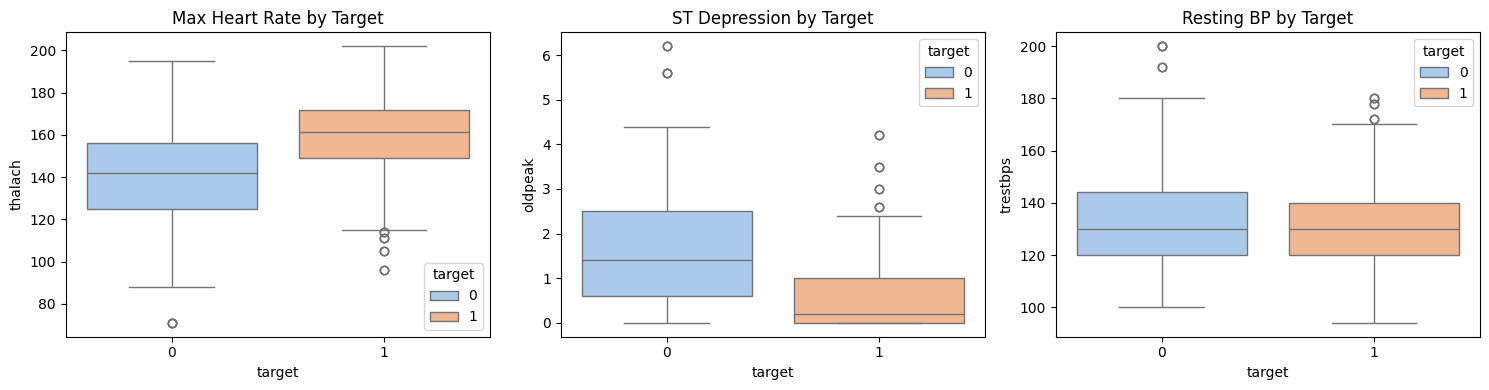

In [187]:
# Pairwise Clinical Profile: Disease vs. No-Disease Cohorts
# Summary stats comparison
disease_stats = df[df['target'] == 1][['trestbps', 'chol', 'thalach', 'oldpeak']].describe()
no_disease_stats = df[df['target'] == 0][['trestbps', 'chol', 'thalach', 'oldpeak']].describe()

print("Heart Disease Patients (Target = 1):\n", disease_stats.round(1))
print("\nNon-Heart Disease Patients (Target = 0):\n", no_disease_stats.round(1))

# Boxplot comparison for key numeric metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='target', y='thalach',hue="target", ax=axes[0], palette='pastel')
axes[0].set_title('Max Heart Rate by Target')

sns.boxplot(data=df, x='target', y='oldpeak',hue="target", ax=axes[1], palette='pastel')
axes[1].set_title('ST Depression by Target')

sns.boxplot(data=df, x='target', y='trestbps',hue="target", ax=axes[2], palette='pastel')
axes[2].set_title('Resting BP by Target')

plt.tight_layout()
plt.show()

## Advanced Questions

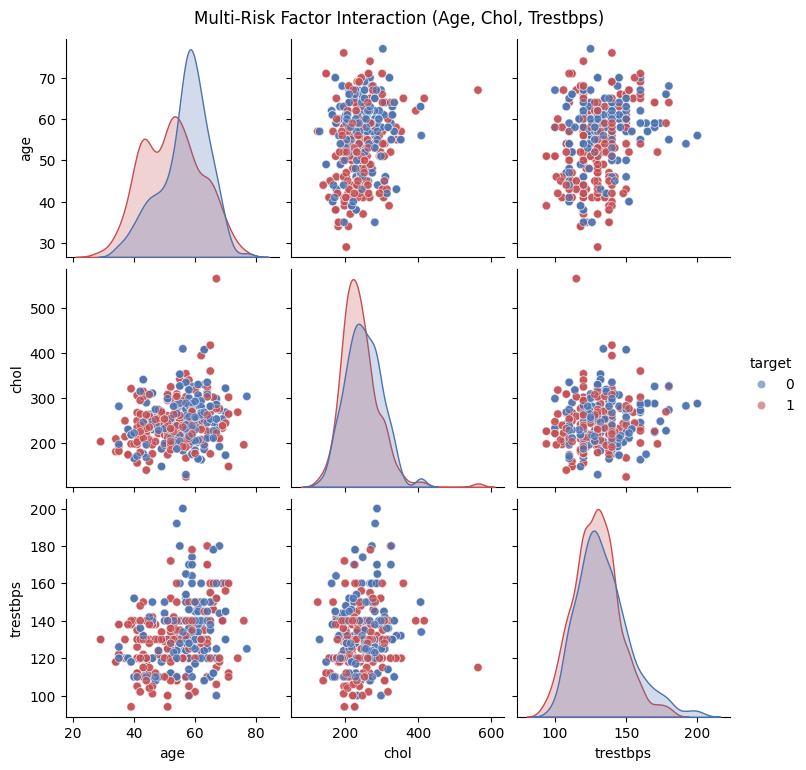

In [188]:
# 1 Combined Effect of Age, Cholesterol, and Blood Pressure on Heart Disease
sns.pairplot(
    df, 
    vars=['age', 'chol', 'trestbps'], 
    hue='target', 
    palette={0: '#4C72B0', 1: '#C44E52'}, 
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Multi-Risk Factor Interaction (Age, Chol, Trestbps)', y=1.02)
plt.show()

> ****Neither high cholesterol nor high blood pressure alone guarantees heart disease, but the overlap of elevated resting blood pressure ($>130\text{ mm Hg}$) with advancing age noticeably clusters positive diagnoses (target = 1)****

Feature Correlations with Heart Disease (Target):

oldpeak    -0.438
exang      -0.438
ca         -0.382
thal       -0.338
sex        -0.280
age        -0.229
trestbps   -0.139
chol       -0.100
fbs        -0.041
restecg     0.134
slope       0.346
thalach     0.423
cp          0.435
target      1.000
Name: target, dtype: float64


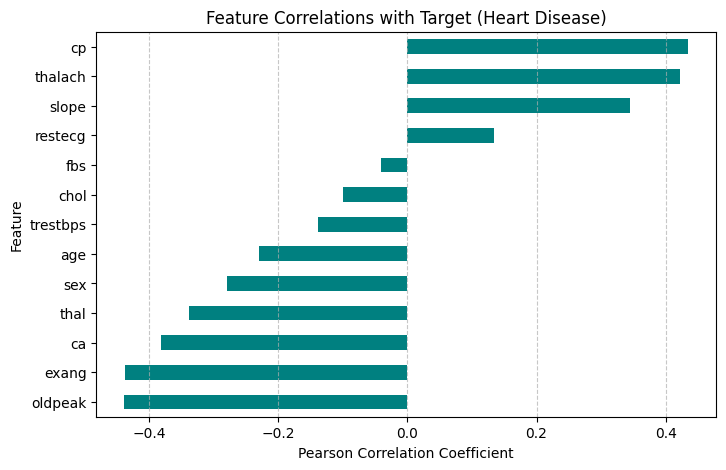

In [189]:
# 2 Clinical Measurements with the Strongest Target Correlation

# Compute and rank feature correlations with heart disease diagnosis
correlations = df.corr(numeric_only=True)['target'].sort_values()
print("Feature Correlations with Heart Disease (Target):\n")
print(correlations.round(3))

# Plot correlation rankings
plt.figure(figsize=(8, 5))
correlations.drop('target').plot(kind='barh', color='teal')
plt.title('Feature Correlations with Target (Heart Disease)')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

> **Chest pain type (cp), maximum heart rate (thalach), and ST slope show the strongest positive relationships with the target, while exercise-induced angina (exang), ST depression (oldpeak), and vessel blockages (ca) show strong inverse relationships.**

In [190]:
#3 Logistic Regression Modeling & Feature Importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Feature matrix and target
X = df.drop(columns=['target', 'age_group'], errors='ignore')
y = df['target']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standardization & Model Fitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 4. Evaluation
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

# 5. Model Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nModel Coefficients:\n", coef_df.to_string(index=False))

Confusion Matrix:
 [[70 30]
 [ 9 96]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205

ROC-AUC Score: 0.930

Model Coefficients:
  Feature  Coefficient
      cp     0.867769
 thalach     0.411778
   slope     0.365533
 restecg     0.163175
     fbs    -0.016271
     age    -0.116839
    chol    -0.275126
trestbps    -0.362392
    thal    -0.499174
   exang    -0.517055
 oldpeak    -0.614295
      ca    -0.745506
     sex    -0.781747


### Model Diagnostics & Clinical Interpretation

> **Diagnostic Performance:**
> The model achieved an **ROC-AUC of 0.930** and a **Recall of 91% (0.91)** on positive cardiac cases, correctly identifying 96 out of 105 at-risk individuals with only 9 False Negatives.

> **Operational Impact for HealthPulse Analytics:**
> 1. **Automated Triage Screening:** Prioritizing recall over raw precision ensures that at-risk patients are flagged for secondary clinical review before acute cardiac events occur.
> 2. **Key Feature Signals:** Chest pain classification (`cp`), vessel blockage counts (`ca`), ST depression (`oldpeak`), and peak heart rate (`thalach`) represent the highest predictive leverage, allowing diagnostic centers to streamline intake panels and prioritize specialized cardiology referrals.

ST Slope Distribution across Chest Pain Types (%):
 slope      0      1      2
cp                        
0       8.45  58.75  32.80
1       4.79  24.55  70.66
2       5.28  38.73  55.99
3      11.69  50.65  37.66


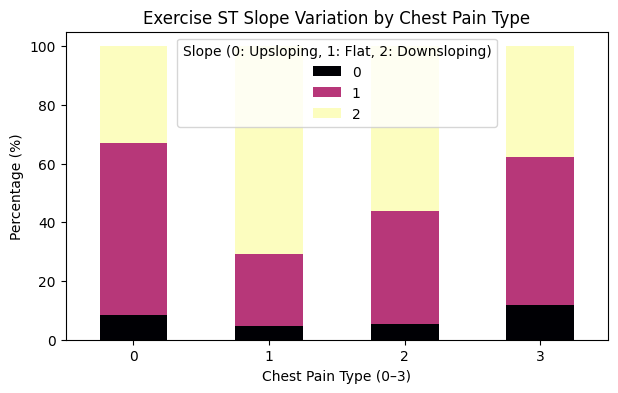

In [191]:
# 4 ST Segment Slope (slope) vs. Chest Pain Types (cp)

# Crosstab of ST slope across chest pain categories
slope_cp_dist = pd.crosstab(df['cp'], df['slope'], normalize='index') * 100
print("ST Slope Distribution across Chest Pain Types (%):\n", slope_cp_dist.round(2))

# Stacked bar plot
slope_cp_dist.plot(kind='bar', stacked=True, colormap='magma', figsize=(7, 4))
plt.title('Exercise ST Slope Variation by Chest Pain Type')
plt.xlabel('Chest Pain Type (0–3)')
plt.ylabel('Percentage (%)')
plt.legend(title='Slope (0: Upsloping, 1: Flat, 2: Downsloping)')
plt.xticks(rotation=0)
plt.show()

 **Key Insight:**
> * **Asymptomatic Patients (`cp = 0`):** Dominated by **Flat ST slopes (`slope = 1`) at 58.75%**, indicating standard ischemic stress during exertion.
> * **Anginal & Non-Anginal Patients (`cp = 1, 2`):** Display a high prevalence of **Downsloping ST segments (`slope = 2`)** at **70.66%** and **55.99%**, which strongly correlates with acute exercise-induced myocardial ischemia.
> * **Severe / Stunned Pain (`cp = 3`):** Half (**50.65%**) exhibit flat slopes, showing impaired cardiac repolarization under stress.

> **Operational & Business Impact for HealthPulse Analytics:**
> 1. **Automated Stress-Test Escalation:** Patients presenting with chest pain types 1 or 2 alongside downsloping ST segments (`slope = 2`) should be routed to fast-track echocardiography or catheterization triage, reducing diagnostic turnaround time.
> 2. **Protocols for Silent Ischemia:** For asymptomatic patients (`cp = 0`), the high rate of flat ST slopes (`slope = 1`) suggests that relying solely on chest pain symptoms will undercount risk. Diagnostic checkups must mandate ECG treadmill testing for older or comorbid cohorts regardless of whether they report chest pain.**

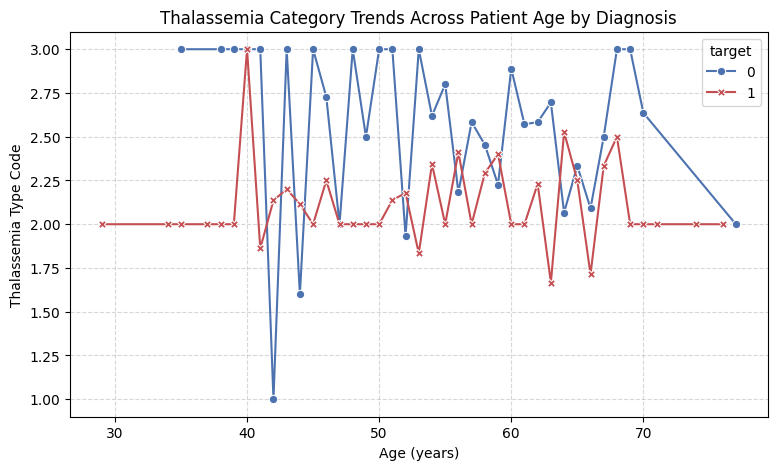

In [192]:
# 5.Thalassemia Types Across Age and Disease Status

# Trend analysis of thalassemia categories across age brackets
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df, 
    x='age', 
    y='thal', 
    hue='target', 
    style='target', 
    markers=True, 
    dashes=False, 
    palette={0: '#4C72B0', 1: '#C44E52'},
    errorbar=None
)
plt.title('Thalassemia Category Trends Across Patient Age by Diagnosis')
plt.xlabel('Age (years)')
plt.ylabel('Thalassemia Type Code')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

> **Tracks how blood-flow defect categories (thal) present across the age spectrum in both healthy and cardiac-compromised groups.**